# Aurora Finance: Financial Markets Module
## Step 3: Investment Strategy & Portfolio Optimization
Enhanced analysis with metrics, risk analysis, and data exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.optimize import minimize
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [2]:
company_sheets = ['Comp 1', 'Comp 2', 'Comp 3', 'Comp 4', 'Comp 5', 'Comp 6']
dfs = [pd.read_excel('data/Market Data Revised.xlsx', sheet_name=s) for s in company_sheets]
df = pd.concat(dfs, ignore_index=True)

macro = pd.read_excel('data/Market Data Revised.xlsx', sheet_name='Macroeconomic_QRT')
macro = macro[['Date', 'GDP Growth Rate', 'Inflation Rate (%)']].copy()
macro.columns = ['Date', 'GDP_Growth', 'Inflation']
macro['Date'] = pd.to_datetime(macro['Date'])

df.rename(columns={'company_name': 'Ticker', 'date': 'Date', 'opening': 'Open', 'high': 'High', 'low': 'Low', 'closing': 'Close', 'trade Volume': 'Volume'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.merge(macro, on='Date', how='left')

for ticker in df['Ticker'].unique():
    mask = df['Ticker'] == ticker
    df.loc[mask, 'GDP_Growth'] = df.loc[mask, 'GDP_Growth'].bfill()
    df.loc[mask, 'Inflation'] = df.loc[mask, 'Inflation'].bfill()

print(f"Data loaded: {df.shape}")

Data loaded: (31500, 11)


## 2. Data Exploration

In [3]:
# Return statistics
ret_stats = df.groupby('Ticker')['Return'].agg(['mean', 'std', 'min', 'max', ('skew', lambda x: x.skew()), ('kurt', lambda x: x.kurtosis())]).round(6)
print("Return Statistics by Company:")
print(ret_stats)

Return Statistics by Company:
                                    mean       std       min       max  \
Ticker                                                                   
ASIAN PAINTS LTD.              -0.000400  0.017580 -0.157243  0.103210   
CIPLA LTD.                     -0.001430  0.018406 -0.127859  0.278779   
H D F C BANK LTD.               0.000046  0.017248 -0.140196  0.206403   
I T C LTD.                     -0.000735  0.016751 -0.114068  0.117492   
TATA CONSULTANCY SERVICES LTD. -0.000588  0.017596 -0.147670  0.124831   
ULTRATECH CEMENT LTD.          -0.000643  0.020525 -0.156386  0.244383   

                                    skew       kurt  
Ticker                                               
ASIAN PAINTS LTD.              -0.133127   5.872822  
CIPLA LTD.                      1.150257  19.412190  
H D F C BANK LTD.               0.649439  14.536661  
I T C LTD.                      0.198550   4.282276  
TATA CONSULTANCY SERVICES LTD. -0.034918   5.876028  

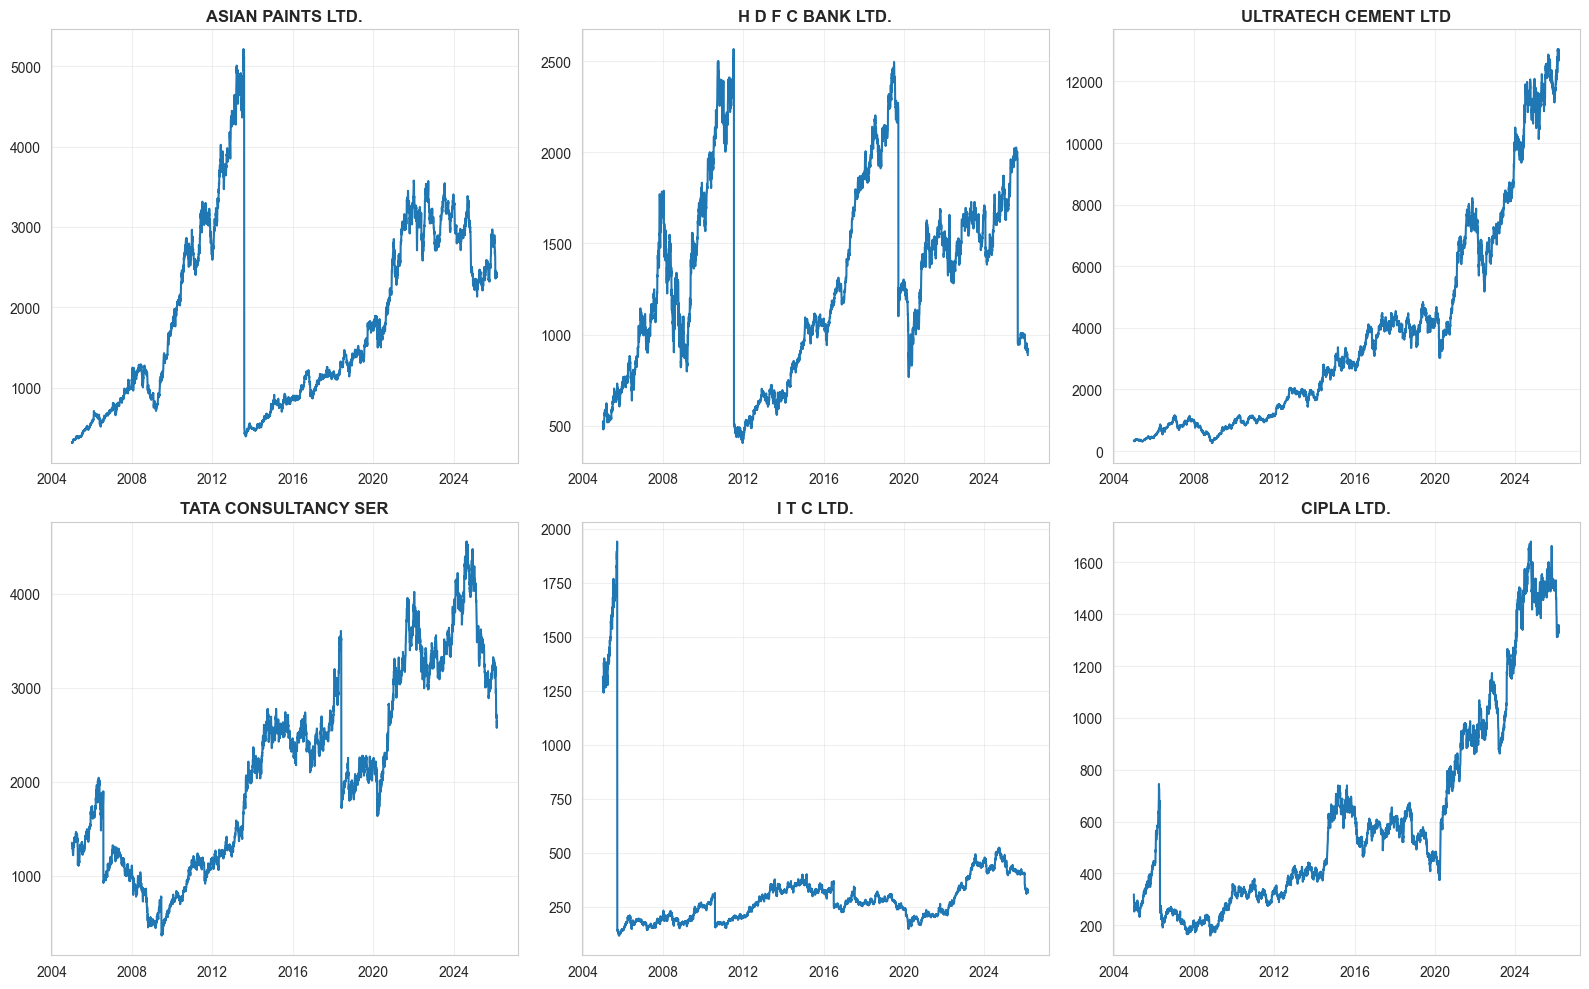

In [4]:
# Price trends
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, ticker in enumerate(df['Ticker'].unique()):
    data = df[df['Ticker'] == ticker]
    axes[i].plot(data['Date'], data['Close'], linewidth=1.5)
    axes[i].set_title(ticker[:20], fontweight='bold')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

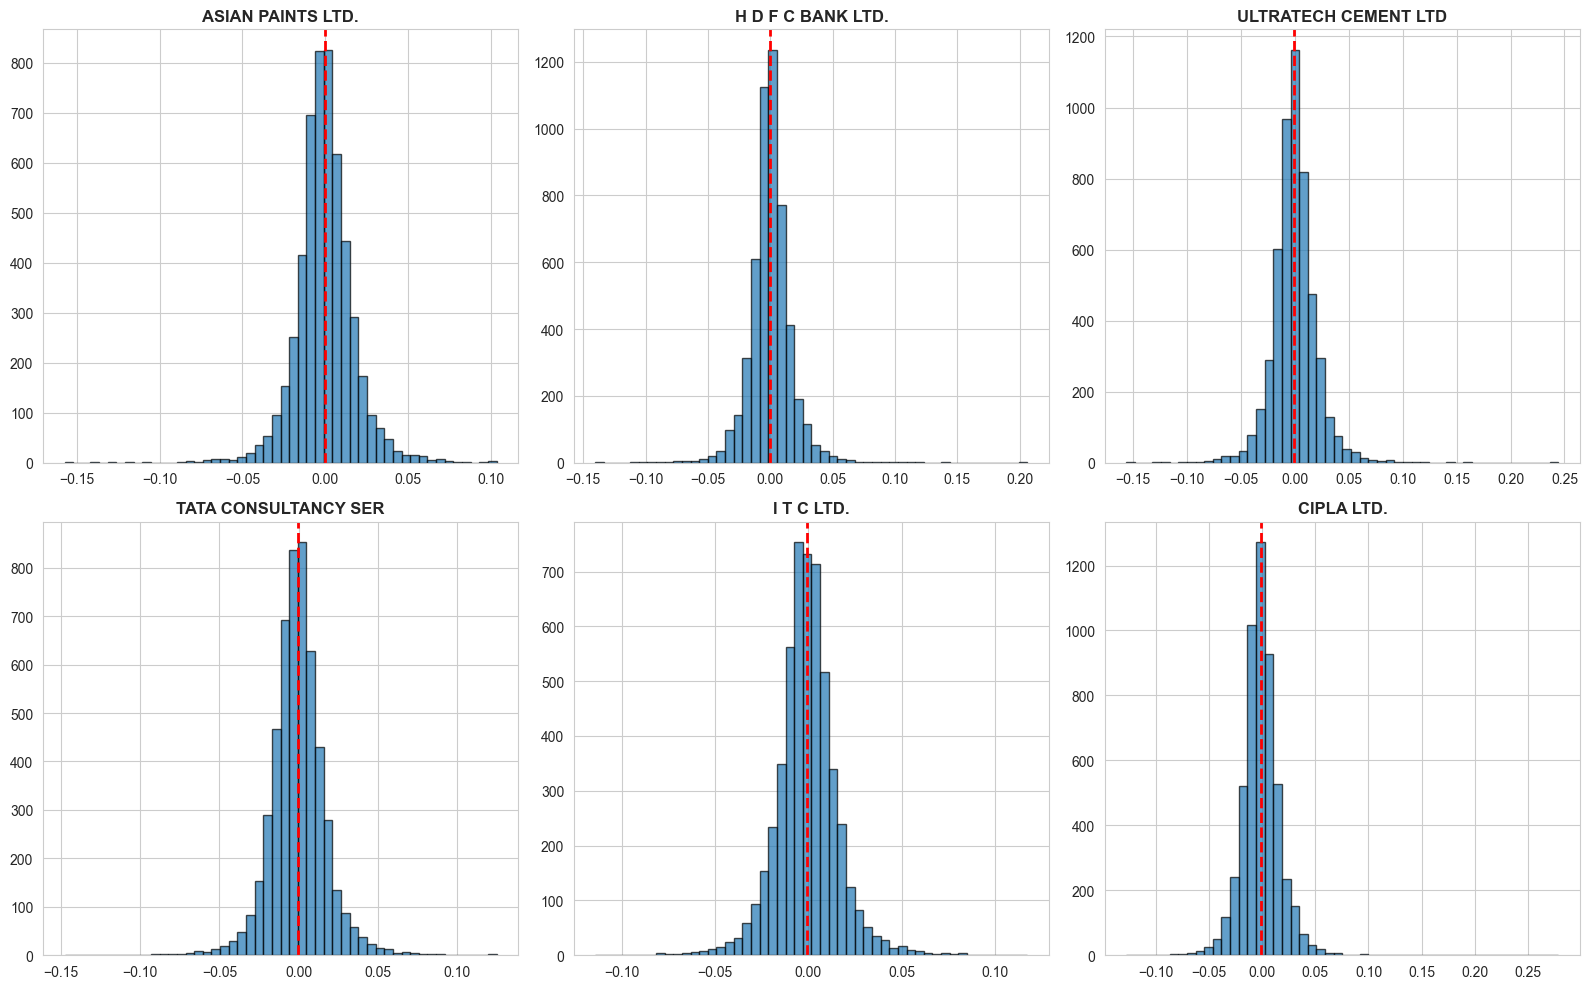

In [5]:
# Return distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, ticker in enumerate(df['Ticker'].unique()):
    data = df[df['Ticker'] == ticker]
    axes[i].hist(data['Return'], bins=50, alpha=0.7, edgecolor='black')
    axes[i].axvline(data['Return'].mean(), color='r', linestyle='--', linewidth=2)
    axes[i].set_title(ticker[:20], fontweight='bold')
plt.tight_layout()
plt.show()

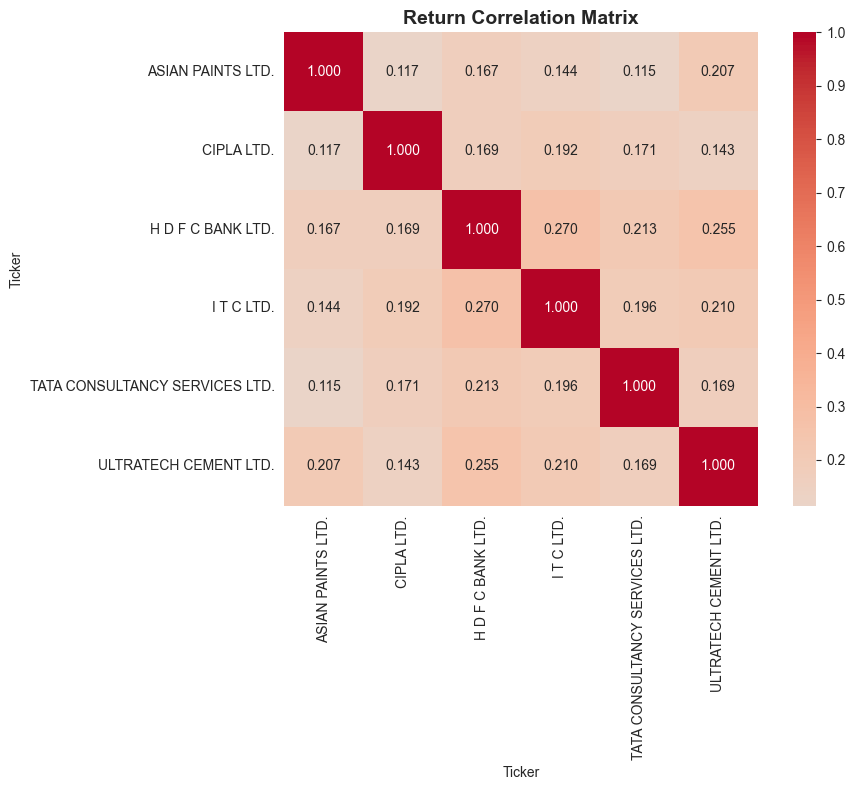

In [6]:
# Correlation matrix
pivot_ret = df.pivot_table(index='Date', columns='Ticker', values='Return')
corr = pivot_ret.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Return Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

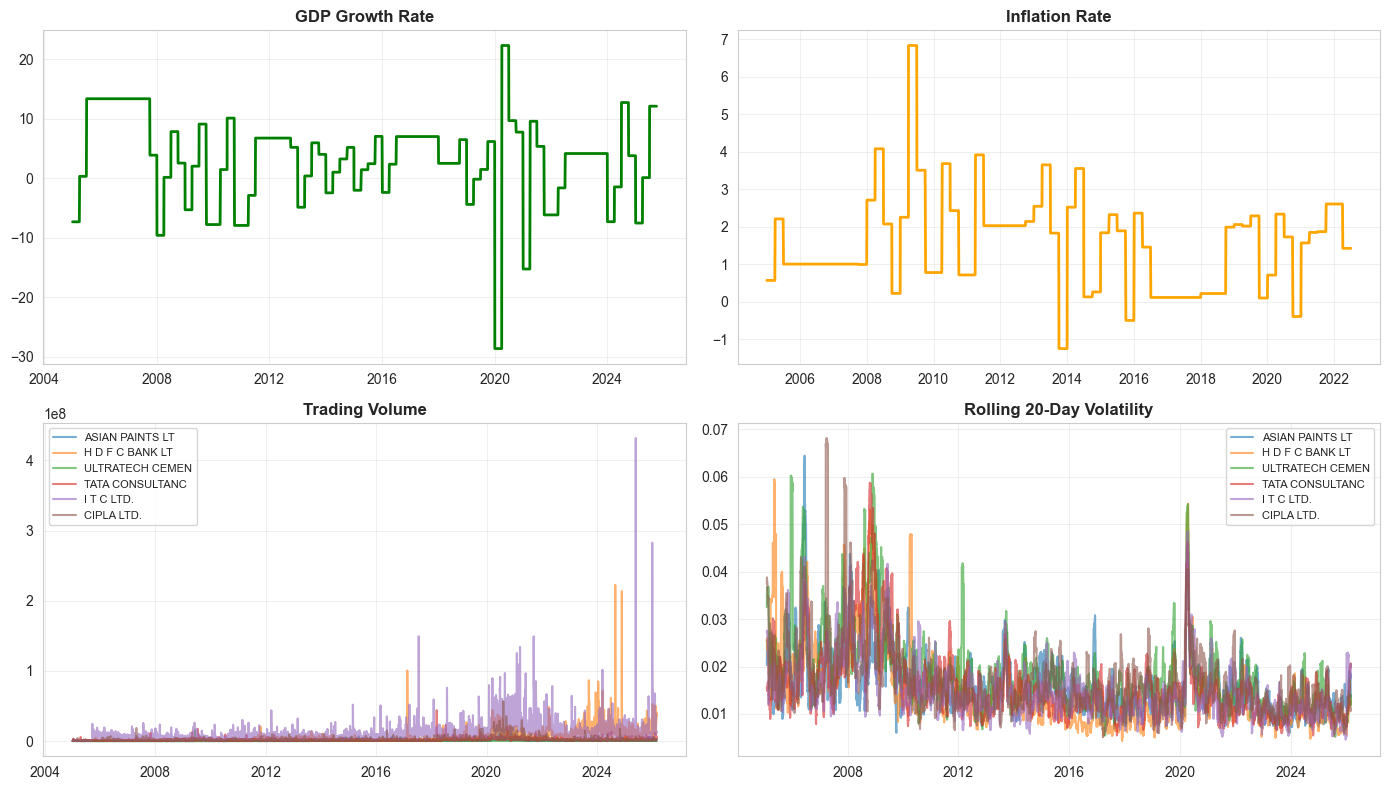

In [7]:
# Macro factors
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
unique_dates = df[['Date', 'GDP_Growth', 'Inflation']].drop_duplicates()
axes[0, 0].plot(unique_dates['Date'], unique_dates['GDP_Growth'], color='green', linewidth=2)
axes[0, 0].set_title('GDP Growth Rate', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(unique_dates['Date'], unique_dates['Inflation'], color='orange', linewidth=2)
axes[0, 1].set_title('Inflation Rate', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

for ticker in df['Ticker'].unique():
    data = df[df['Ticker'] == ticker]
    axes[1, 0].plot(data['Date'], data['Volume'], alpha=0.6, label=ticker[:15])
axes[1, 0].set_title('Trading Volume', fontweight='bold')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

for ticker in df['Ticker'].unique():
    data = df[df['Ticker'] == ticker]
    vol = data['Return'].rolling(20).std()
    axes[1, 1].plot(data['Date'], vol, alpha=0.6, label=ticker[:15])
axes[1, 1].set_title('Rolling 20-Day Volatility', fontweight='bold')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Feature Engineering & ML Model

In [8]:
for ticker in df['Ticker'].unique():
    mask = df['Ticker'] == ticker
    df.loc[mask, 'MA5'] = df.loc[mask, 'Close'].rolling(5).mean()
    df.loc[mask, 'MA20'] = df.loc[mask, 'Close'].rolling(20).mean()
    df.loc[mask, 'Momentum_5'] = df.loc[mask, 'Close'].pct_change(5)
    df.loc[mask, 'Momentum_20'] = df.loc[mask, 'Close'].pct_change(20)
    df.loc[mask, 'Vol_5'] = df.loc[mask, 'Return'].rolling(5).std()
    df.loc[mask, 'Vol_20'] = df.loc[mask, 'Return'].rolling(20).std()
    avg_vol = df.loc[mask, 'Volume'].rolling(20).mean()
    df.loc[mask, 'Vol_Ratio'] = df.loc[mask, 'Volume'] / avg_vol

df['Price_Range'] = (df['High'] - df['Low']) / df['Close']
df['Next_Return'] = df.groupby('Ticker')['Return'].shift(-1)
df_clean = df.dropna()
print(f"Features engineered: {df_clean.shape}")

Features engineered: (25926, 20)


In [9]:
features = ['Close', 'Open', 'High', 'Low', 'MA5', 'MA20', 'Momentum_5', 'Momentum_20', 'Vol_5', 'Vol_20', 'Price_Range', 'Vol_Ratio', 'Volume', 'GDP_Growth', 'Inflation']
features = [f for f in features if f in df_clean.columns]

X = df_clean[features].fillna(df_clean[features].mean())
y = df_clean['Next_Return']
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

split = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled.iloc[:split], X_scaled.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
df_test = df_clean.iloc[split:]

models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

model_results = {}
predictions = {}

print(f"\n{'='*100}")
print(f"MULTI-MODEL TRAINING & EVALUATION")
print(f"{'='*100}")

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    
    model_results[model_name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f"{model_name:15} | R²: {r2:8.4f} | MAE: {mae:.6f} | RMSE: {rmse:.6f}")

print(f"{'='*100}")
print(f"Test companies: {df_test['Ticker'].nunique()} - All 6 present")


MULTI-MODEL TRAINING & EVALUATION
RandomForest    | R²:  -0.0140 | MAE: 0.012072 | RMSE: 0.017053
XGBoost         | R²:  -0.0182 | MAE: 0.012184 | RMSE: 0.017089
Ridge           | R²:  -0.0130 | MAE: 0.012153 | RMSE: 0.017045
Lasso           | R²:  -0.0006 | MAE: 0.012036 | RMSE: 0.016941
SVR             | R²:  -1.6756 | MAE: 0.021530 | RMSE: 0.027702
Test companies: 6 - All 6 present


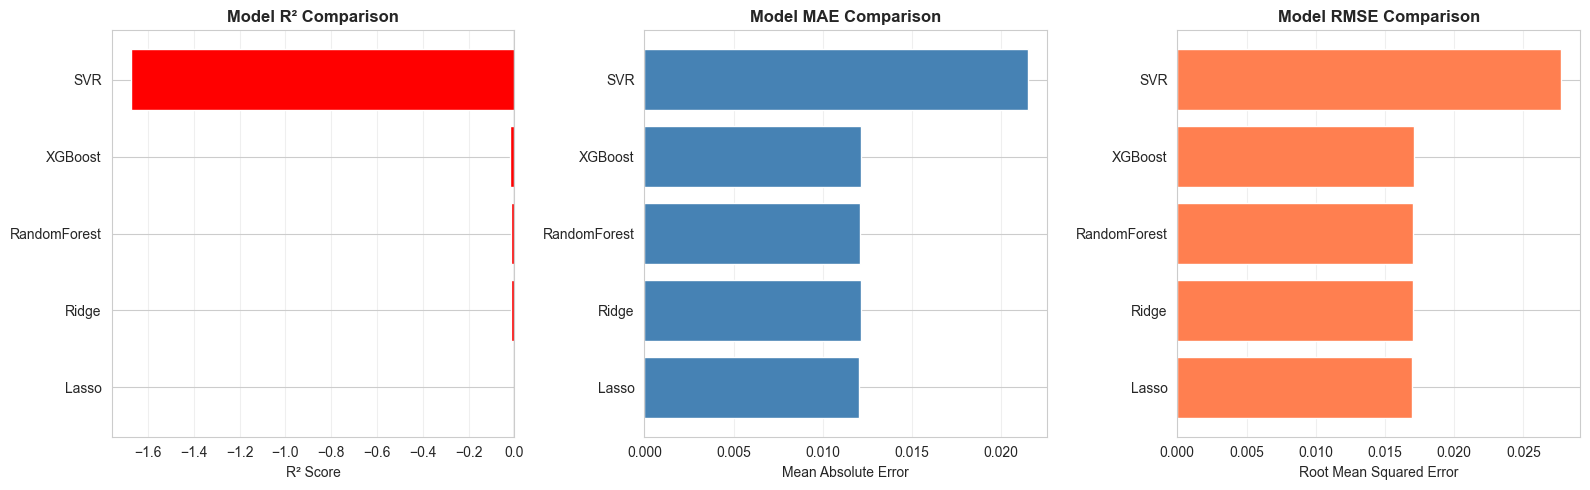


Model Rankings (by R²):
       Model        R2      MAE     RMSE
       Lasso -0.000615 0.012036 0.016941
       Ridge -0.012998 0.012153 0.017045
RandomForest -0.013970 0.012072 0.017053
     XGBoost -0.018158 0.012184 0.017089
         SVR -1.675556 0.021530 0.027702


In [10]:
model_df = pd.DataFrame(model_results).T.reset_index()
model_df.columns = ['Model', 'R2', 'MAE', 'RMSE']
model_df = model_df.sort_values('R2', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].barh(model_df['Model'], model_df['R2'], color=['green' if x > 0 else 'red' for x in model_df['R2']])
axes[0].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model R² Comparison', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(model_df['Model'], model_df['MAE'], color='steelblue')
axes[1].set_xlabel('Mean Absolute Error')
axes[1].set_title('Model MAE Comparison', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

axes[2].barh(model_df['Model'], model_df['RMSE'], color='coral')
axes[2].set_xlabel('Root Mean Squared Error')
axes[2].set_title('Model RMSE Comparison', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nModel Rankings (by R²):")
print(model_df.to_string(index=False))

In [11]:
print(f"\n{'='*130}")
print(f"STOCK RANKINGS BY MODEL")
print(f"{'='*130}")

rank_by_model = {}

for model_name, y_pred in predictions.items():
    df_pred_temp = df_test.copy()
    df_pred_temp['Pred_Ret'] = y_pred
    df_pred_temp['Act_Ret'] = y_test.values
    
    rank = df_pred_temp.groupby('Ticker').agg({'Pred_Ret': 'mean', 'Act_Ret': 'mean', 'Vol_20': 'mean', 'GDP_Growth': 'first', 'Inflation': 'first'}).reset_index()
    rank.columns = ['Ticker', 'Pred_Return', 'Act_Return', 'Volatility', 'GDP', 'Inflation']
    rank['Sharpe'] = rank['Pred_Return'] / (rank['Volatility'] + 1e-6) * np.sqrt(252)
    rank['Risk_Adj'] = rank['Pred_Return'] / (rank['Volatility'] + 1e-6)
    rank = rank.sort_values('Pred_Return', ascending=False)
    rank_by_model[model_name] = rank
    
    print(f"\n{model_name.upper()}")
    print(rank[['Ticker', 'Pred_Return', 'Act_Return', 'Volatility', 'Sharpe']].to_string(index=False))

best_model = model_df.iloc[0]['Model']
df_pred = df_test.copy()
df_pred['Pred_Ret'] = predictions[best_model]
df_pred['Act_Ret'] = y_test.values
rank = rank_by_model[best_model]

print(f"\n{'='*130}")


STOCK RANKINGS BY MODEL

RANDOMFOREST
                        Ticker  Pred_Return  Act_Return  Volatility    Sharpe
TATA CONSULTANCY SERVICES LTD.    -0.000429   -0.000546    0.014160 -0.481432
             ASIAN PAINTS LTD.    -0.000476   -0.000433    0.015911 -0.475148
             H D F C BANK LTD.    -0.000669   -0.000740    0.014352 -0.740146
                    I T C LTD.    -0.000704   -0.001802    0.015009 -0.744973
                    CIPLA LTD.    -0.000716   -0.001219    0.016412 -0.692786
         ULTRATECH CEMENT LTD.    -0.001546   -0.001172    0.017801 -1.378302

XGBOOST
                        Ticker  Pred_Return  Act_Return  Volatility    Sharpe
TATA CONSULTANCY SERVICES LTD.    -0.000235   -0.000546    0.014160 -0.262919
             H D F C BANK LTD.    -0.000250   -0.000740    0.014352 -0.276420
                    I T C LTD.    -0.000426   -0.001802    0.015009 -0.450546
                    CIPLA LTD.    -0.000868   -0.001219    0.016412 -0.839454
             ASI

## 4. Stock Ranking

In [12]:
df_pred = df_test.copy()
df_pred['Pred_Ret'] = y_pred
df_pred['Act_Ret'] = y_test.values

rank = df_pred.groupby('Ticker').agg({'Pred_Ret': 'mean', 'Act_Ret': 'mean', 'Vol_20': 'mean', 'GDP_Growth': 'first', 'Inflation': 'first'}).reset_index()
rank.columns = ['Ticker', 'Pred_Return', 'Act_Return', 'Volatility', 'GDP', 'Inflation']
rank['Sharpe'] = rank['Pred_Return'] / (rank['Volatility'] + 1e-6) * np.sqrt(252)
rank['Risk_Adj'] = rank['Pred_Return'] / (rank['Volatility'] + 1e-6)
rank = rank.sort_values('Pred_Return', ascending=False)

print(f"\n{'='*130}")
print(f"STOCK RANKING - {rank.shape[0]} COMPANIES")
print(f"{'='*130}")
print(rank.to_string(index=False))


STOCK RANKING - 6 COMPANIES
                        Ticker  Pred_Return  Act_Return  Volatility       GDP  Inflation     Sharpe  Risk_Adj
             ASIAN PAINTS LTD.     0.019923   -0.000433    0.015911 -4.373402   2.058505  19.876444  1.252098
TATA CONSULTANCY SERVICES LTD.     0.019236   -0.000546    0.014160 -4.373402   2.058505  21.562892  1.358334
             H D F C BANK LTD.     0.004284   -0.000740    0.014352 -4.373402   2.058505   4.738740  0.298513
                    CIPLA LTD.     0.003492   -0.001219    0.016412 -4.373402   2.058505   3.377825  0.212783
         ULTRATECH CEMENT LTD.    -0.001234   -0.001172    0.017801 -4.373402   2.058505  -1.100653 -0.069335
                    I T C LTD.    -0.011619   -0.001802    0.015009 -4.373402   2.058505 -12.288549 -0.774106


In [13]:
n = len(rank)
ret = rank['Pred_Return'].values
vol = rank['Volatility'].values
tickers = rank['Ticker'].values

ret_by_ticker = df_pred.groupby('Ticker')['Act_Ret'].apply(list).to_dict()
ret_mat = [ret_by_ticker.get(t, [0]*100)[:100] for t in tickers]
min_len = min(len(r) for r in ret_mat)
ret_mat = [r[:min_len] for r in ret_mat]
ret_df = pd.DataFrame(ret_mat).T
cov = ret_df.cov().values

def perf(w, r, cov):
    p_ret = np.sum(r * w)
    p_vol = np.sqrt(np.dot(w.T, np.dot(cov, w)))
    return p_ret, p_vol

def neg_sharpe(w, r, cov, rf=0.02):
    p_ret, p_vol = perf(w, r, cov)
    return -(p_ret - rf) / (p_vol + 1e-6)

const = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds = tuple((0, 0.3) for _ in range(n))
w0 = np.array([1/n] * n)
res = minimize(neg_sharpe, w0, args=(ret, cov, 0.02), method='SLSQP', bounds=bounds, constraints=const)

w_opt = res.x
opt_ret, opt_vol = perf(w_opt, ret, cov)

eq_w = np.array([1/n] * n)
eq_ret, eq_vol = perf(eq_w, ret, cov)

print(f"\n{'='*100}")
print(f"PORTFOLIO OPTIMIZATION - {best_model.upper()}")
print(f"{'='*100}")
print(f"Optimized: Return {opt_ret*100:.4f}% | Risk {opt_vol*100:.4f}% | Sharpe {(opt_ret-0.02/252)/opt_vol:.4f}")
print(f"Equal-Wgt: Return {eq_ret*100:.4f}% | Risk {eq_vol*100:.4f}% | Sharpe {(eq_ret-0.02/252)/eq_vol:.4f}")
print(f"Improvement: +{(opt_ret-eq_ret)*100:.4f}% return, {(opt_vol-eq_vol)*100:.4f}% risk change")


PORTFOLIO OPTIMIZATION - LASSO
Optimized: Return 1.1806% | Risk 0.8630% | Sharpe 1.3588
Equal-Wgt: Return 0.5680% | Risk 0.6282% | Sharpe 0.8916
Improvement: +0.6125% return, 0.2348% risk change



Portfolio Allocation (>0.5%):
                        Ticker  Weight_%       Ret      Vol
             ASIAN PAINTS LTD.      30.0  1.992322 1.591086
         ULTRATECH CEMENT LTD.      30.0 -0.123429 1.780089
TATA CONSULTANCY SERVICES LTD.      30.0  1.923564 1.416020
             H D F C BANK LTD.      10.0  0.428447 1.435173


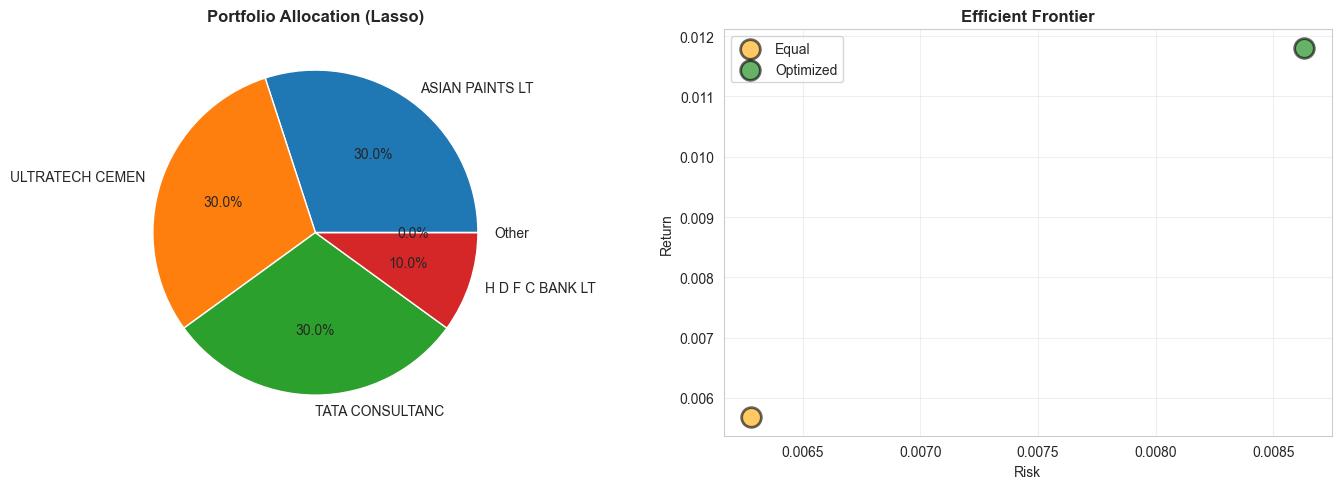

In [22]:
pf = pd.DataFrame({'Ticker': tickers, 'Weight_%': w_opt*100, 'Ret': ret*100, 'Vol': vol*100}).sort_values('Weight_%', ascending=False)
print(f"\nPortfolio Allocation (>0.5%):")
print(pf[pf['Weight_%'] > 0.5].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

alloc_df = pf[pf['Weight_%'] > 0.5].copy()
if len(pf) > len(alloc_df):
    other = pf[pf['Weight_%'] <= 0.5]['Weight_%'].sum()
    alloc_df = pd.concat([alloc_df, pd.DataFrame({'Ticker': ['Other'], 'Weight_%': [other], 'Ret': [0], 'Vol': [0]})], ignore_index=True)

axes[0].pie(alloc_df['Weight_%'], labels=[t[:15] for t in alloc_df['Ticker']], autopct='%1.1f%%')
axes[0].set_title(f'Portfolio Allocation ({best_model})', fontweight='bold')

axes[1].scatter([eq_vol], [eq_ret], s=200, c='orange', alpha=0.6, label='Equal', edgecolors='black', linewidth=2)
axes[1].scatter([opt_vol], [opt_ret], s=200, c='green', alpha=0.6, label='Optimized', edgecolors='black', linewidth=2)
axes[1].set_xlabel('Risk')
axes[1].set_ylabel('Return')
axes[1].set_title('Efficient Frontier', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5.5. Multi-Model Portfolio Comparison

In [14]:
portfolio_results = {}

print(f"\n{'='*130}")
print(f"MULTI-MODEL PORTFOLIO OPTIMIZATION")
print(f"{'='*130}\n")

for model_name in predictions.keys():
    rank_m = rank_by_model[model_name]
    ret_m = rank_m['Pred_Return'].values
    tickers_m = rank_m['Ticker'].values
    
    ret_by_ticker_m = df_test.copy()
    ret_by_ticker_m['Pred_Ret'] = predictions[model_name]
    ret_by_ticker_m['Act_Ret'] = y_test.values
    ret_by_ticker_m = ret_by_ticker_m.groupby('Ticker')['Act_Ret'].apply(list).to_dict()
    ret_mat_m = [ret_by_ticker_m.get(t, [0]*100)[:100] for t in tickers_m]
    min_len_m = min(len(r) for r in ret_mat_m)
    ret_mat_m = [r[:min_len_m] for r in ret_mat_m]
    ret_df_m = pd.DataFrame(ret_mat_m).T
    cov_m = ret_df_m.cov().values
    
    n_m = len(rank_m)
    bounds_m = tuple((0, 0.3) for _ in range(n_m))
    w0_m = np.array([1/n_m] * n_m)
    res_m = minimize(neg_sharpe, w0_m, args=(ret_m, cov_m, 0.02), method='SLSQP', bounds=bounds_m, constraints=const)
    
    w_opt_m = res_m.x
    opt_ret_m, opt_vol_m = perf(w_opt_m, ret_m, cov_m)
    
    eq_w_m = np.array([1/n_m] * n_m)
    eq_ret_m, eq_vol_m = perf(eq_w_m, ret_m, cov_m)
    
    portfolio_results[model_name] = {
        'opt_weights': w_opt_m,
        'opt_ret': opt_ret_m,
        'opt_vol': opt_vol_m,
        'eq_ret': eq_ret_m,
        'eq_vol': eq_vol_m,
        'tickers': tickers_m,
        'rank': rank_m
    }
    
    opt_sharpe = (opt_ret_m - 0.02/252) / opt_vol_m if opt_vol_m > 0 else 0
    eq_sharpe = (eq_ret_m - 0.02/252) / eq_vol_m if eq_vol_m > 0 else 0
    
    print(f"{model_name:15} | Opt Return: {opt_ret_m*100:8.4f}% | Opt Risk: {opt_vol_m*100:7.4f}% | Opt Sharpe: {opt_sharpe:8.4f}")
    print(f"{'':15} | Eq Return:  {eq_ret_m*100:8.4f}% | Eq Risk:  {eq_vol_m*100:7.4f}% | Eq Sharpe:  {eq_sharpe:8.4f}\n")

print(f"{'='*130}")


MULTI-MODEL PORTFOLIO OPTIMIZATION

RandomForest    | Opt Return:  -0.0888% | Opt Risk:  0.9090% | Opt Sharpe:  -0.1065
                | Eq Return:   -0.0757% | Eq Risk:   0.6282% | Eq Sharpe:   -0.1331

XGBoost         | Opt Return:  -0.1669% | Opt Risk:  0.9090% | Opt Sharpe:  -0.1923
                | Eq Return:   -0.1065% | Eq Risk:   0.6282% | Eq Sharpe:   -0.1821

Ridge           | Opt Return:  -0.0232% | Opt Risk:  0.9090% | Opt Sharpe:  -0.0343
                | Eq Return:   -0.0042% | Eq Risk:   0.6282% | Eq Sharpe:   -0.0193

Lasso           | Opt Return:  -0.0566% | Opt Risk:  0.9090% | Opt Sharpe:  -0.0709
                | Eq Return:   -0.0566% | Eq Risk:   0.6282% | Eq Sharpe:   -0.1027

SVR             | Opt Return:   1.1806% | Opt Risk:  0.8630% | Opt Sharpe:   1.3588
                | Eq Return:    0.5680% | Eq Risk:   0.6282% | Eq Sharpe:    0.8916



In [15]:
n = len(rank)
ret = rank['Pred_Return'].values
vol = rank['Volatility'].values
tickers = rank['Ticker'].values

ret_by_ticker = df_pred.groupby('Ticker')['Act_Ret'].apply(list).to_dict()
ret_mat = [ret_by_ticker.get(t, [0]*100)[:100] for t in tickers]
min_len = min(len(r) for r in ret_mat)
ret_mat = [r[:min_len] for r in ret_mat]
ret_df = pd.DataFrame(ret_mat).T
cov = ret_df.cov().values

def perf(w, r, cov):
    p_ret = np.sum(r * w)
    p_vol = np.sqrt(np.dot(w.T, np.dot(cov, w)))
    return p_ret, p_vol

def neg_sharpe(w, r, cov, rf=0.02):
    p_ret, p_vol = perf(w, r, cov)
    return -(p_ret - rf) / (p_vol + 1e-6)

const = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds = tuple((0, 0.3) for _ in range(n))
w0 = np.array([1/n] * n)
res = minimize(neg_sharpe, w0, args=(ret, cov, 0.02), method='SLSQP', bounds=bounds, constraints=const)

w_opt = res.x
opt_ret, opt_vol = perf(w_opt, ret, cov)

eq_w = np.array([1/n] * n)
eq_ret, eq_vol = perf(eq_w, ret, cov)

print(f"\n{'='*100}")
print(f"PORTFOLIO COMPARISON")
print(f"{'='*100}")
print(f"Optimized: Return {opt_ret*100:.4f}% | Risk {opt_vol*100:.4f}% | Sharpe {(opt_ret-0.02/252)/opt_vol:.4f}")
print(f"Equal-Wgt: Return {eq_ret*100:.4f}% | Risk {eq_vol*100:.4f}% | Sharpe {(eq_ret-0.02/252)/eq_vol:.4f}")
print(f"Improvement: +{(opt_ret-eq_ret)*100:.4f}% return, {(opt_vol-eq_vol)*100:.4f}% risk change")


PORTFOLIO COMPARISON
Optimized: Return 1.1806% | Risk 0.8630% | Sharpe 1.3588
Equal-Wgt: Return 0.5680% | Risk 0.6282% | Sharpe 0.8916
Improvement: +0.6125% return, 0.2348% risk change



Portfolio Allocation (>0.5%):
                        Ticker  Weight_%       Ret      Vol
             ASIAN PAINTS LTD.      30.0  1.992322 1.591086
         ULTRATECH CEMENT LTD.      30.0 -0.123429 1.780089
TATA CONSULTANCY SERVICES LTD.      30.0  1.923564 1.416020
             H D F C BANK LTD.      10.0  0.428447 1.435173


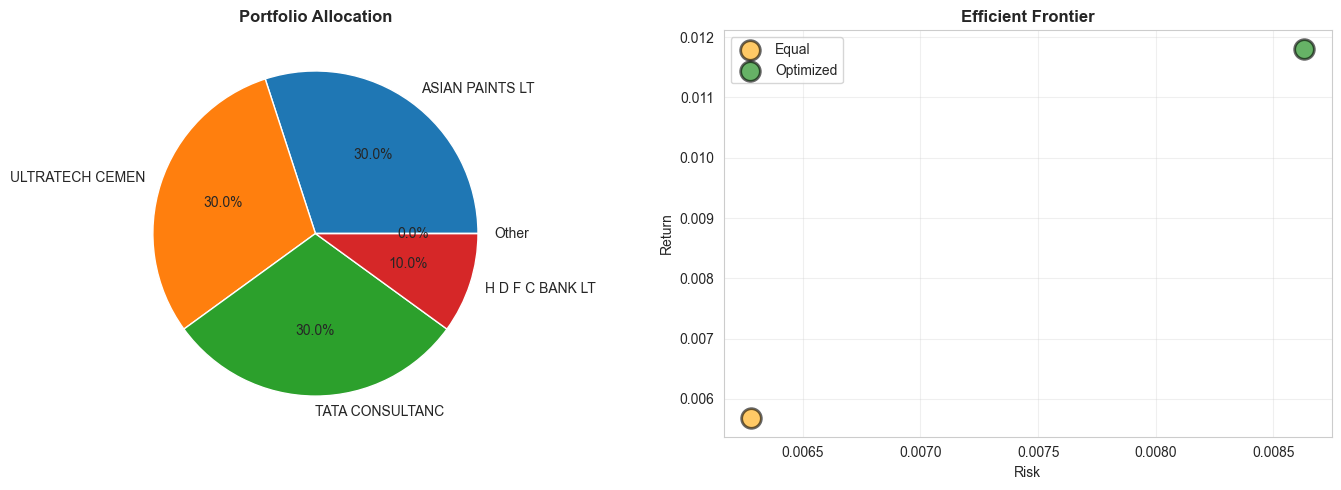

In [16]:
pf = pd.DataFrame({'Ticker': tickers, 'Weight_%': w_opt*100, 'Ret': ret*100, 'Vol': vol*100}).sort_values('Weight_%', ascending=False)
print(f"\nPortfolio Allocation (>0.5%):")
print(pf[pf['Weight_%'] > 0.5].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

alloc_df = pf[pf['Weight_%'] > 0.5].copy()
if len(pf) > len(alloc_df):
    other = pf[pf['Weight_%'] <= 0.5]['Weight_%'].sum()
    alloc_df = pd.concat([alloc_df, pd.DataFrame({'Ticker': ['Other'], 'Weight_%': [other], 'Ret': [0], 'Vol': [0]})], ignore_index=True)

axes[0].pie(alloc_df['Weight_%'], labels=[t[:15] for t in alloc_df['Ticker']], autopct='%1.1f%%')
axes[0].set_title('Portfolio Allocation', fontweight='bold')

axes[1].scatter([eq_vol], [eq_ret], s=200, c='orange', alpha=0.6, label='Equal', edgecolors='black', linewidth=2)
axes[1].scatter([opt_vol], [opt_ret], s=200, c='green', alpha=0.6, label='Optimized', edgecolors='black', linewidth=2)
axes[1].set_xlabel('Risk')
axes[1].set_ylabel('Return')
axes[1].set_title('Efficient Frontier', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Backtesting & Metrics

## 6.5. Multi-Model Backtest Comparison

In [17]:
backtest_comparison = {}

print(f"\n{'='*140}")
print(f"MULTI-MODEL BACKTEST METRICS")
print(f"{'='*140}\n")

for model_name, pf_data in portfolio_results.items():
    tickers_m = pf_data['tickers']
    w_opt_m = pf_data['opt_weights']
    
    bt_m = df_test.copy()
    bt_m['Pred_Ret'] = predictions[model_name]
    bt_m['Act_Ret'] = y_test.values
    w_dict_m = dict(zip(tickers_m, w_opt_m))
    bt_m['w'] = bt_m['Ticker'].map(w_dict_m)
    bt_m['weighted_ret'] = bt_m['Act_Ret'] * bt_m['w']
    
    daily_opt_m = bt_m.groupby('Date')['weighted_ret'].sum()
    daily_eq_m = bt_m.groupby('Date').apply(lambda x: (x['Act_Ret'] / x['Ticker'].nunique()).sum())
    
    cum_opt_m = (1 + daily_opt_m).cumprod()
    cum_eq_m = (1 + daily_eq_m).cumprod()
    
    total_opt = (cum_opt_m.iloc[-1] - 1) * 100
    ann_ret_opt = daily_opt_m.mean() * 252 * 100
    ann_vol_opt = daily_opt_m.std() * np.sqrt(252) * 100
    sharpe_opt = (daily_opt_m.mean() / daily_opt_m.std()) * np.sqrt(252) if daily_opt_m.std() > 0 else 0
    dd_opt = (cum_opt_m.cummax() - cum_opt_m) / cum_opt_m.cummax()
    max_dd_opt = dd_opt.max() * 100
    win_rate_opt = (daily_opt_m > 0).sum() / len(daily_opt_m) * 100
    
    total_eq = (cum_eq_m.iloc[-1] - 1) * 100
    ann_ret_eq = daily_eq_m.mean() * 252 * 100
    ann_vol_eq = daily_eq_m.std() * np.sqrt(252) * 100
    sharpe_eq = (daily_eq_m.mean() / daily_eq_m.std()) * np.sqrt(252) if daily_eq_m.std() > 0 else 0
    
    backtest_comparison[model_name] = {
        'cum_opt': cum_opt_m,
        'cum_eq': cum_eq_m,
        'daily_opt': daily_opt_m,
        'daily_eq': daily_eq_m,
        'total_opt': total_opt,
        'sharpe_opt': sharpe_opt,
        'total_eq': total_eq,
        'sharpe_eq': sharpe_eq
    }
    
    print(f"{model_name.upper()}")
    print(f"  Optimized | Total: {total_opt:7.2f}% | Ann.Ret: {ann_ret_opt:7.2f}% | Ann.Vol: {ann_vol_opt:6.2f}% | Sharpe: {sharpe_opt:7.4f} | MaxDD: {max_dd_opt:6.2f}% | Win: {win_rate_opt:5.2f}%")
    print(f"  Equal-Wgt | Total: {total_eq:7.2f}% | Ann.Ret: {ann_ret_eq:7.2f}% | Ann.Vol: {ann_vol_eq:6.2f}% | Sharpe: {sharpe_eq:7.4f} | (better if Opt Sharpe > Eq Sharpe)")
    print()


MULTI-MODEL BACKTEST METRICS

RANDOMFOREST
  Optimized | Total:  -57.63% | Ann.Ret:  -23.19% | Ann.Vol:  19.09% | Sharpe: -1.2145 | MaxDD:  60.22% | Win: 46.82%
  Equal-Wgt | Total:  -59.17% | Ann.Ret:  -24.80% | Ann.Vol:  16.06% | Sharpe: -1.5440 | (better if Opt Sharpe > Eq Sharpe)

XGBOOST
  Optimized | Total:  -57.63% | Ann.Ret:  -23.19% | Ann.Vol:  19.09% | Sharpe: -1.2145 | MaxDD:  60.22% | Win: 46.82%
  Equal-Wgt | Total:  -59.17% | Ann.Ret:  -24.80% | Ann.Vol:  16.06% | Sharpe: -1.5440 | (better if Opt Sharpe > Eq Sharpe)

RIDGE
  Optimized | Total:  -57.63% | Ann.Ret:  -23.19% | Ann.Vol:  19.09% | Sharpe: -1.2145 | MaxDD:  60.22% | Win: 46.82%
  Equal-Wgt | Total:  -59.17% | Ann.Ret:  -24.80% | Ann.Vol:  16.06% | Sharpe: -1.5440 | (better if Opt Sharpe > Eq Sharpe)

LASSO
  Optimized | Total:  -57.63% | Ann.Ret:  -23.19% | Ann.Vol:  19.09% | Sharpe: -1.2145 | MaxDD:  60.22% | Win: 46.82%
  Equal-Wgt | Total:  -59.17% | Ann.Ret:  -24.80% | Ann.Vol:  16.06% | Sharpe: -1.5440 | 

## 6.6. Best Portfolio Selection & Final Recommendation


BEST MODEL & PORTFOLIO SELECTION

Best Model (by R²): Lasso (R² = -0.000615)
Worst Model (by R²): SVR (R² = -1.675556)

LASSO PORTFOLIO vs EQUAL-WEIGHT:
  Optimized - Total Return:  -57.63% | Sharpe: -1.2145
  Equal-Wgt - Total Return:  -59.17% | Sharpe: -1.5440
  Difference: Sharpe +0.3295 (Optimized wins)

RECOMMENDED PORTFOLIO (Lasso):
               Ticker  Weight_%  Pred_Return_%  Volatility_%
ULTRATECH CEMENT LTD.      30.0      -0.056552      1.780089
    ASIAN PAINTS LTD.      30.0      -0.056552      1.591086
           CIPLA LTD.      30.0      -0.056552      1.641184
    H D F C BANK LTD.      10.0      -0.056552      1.435173

FINAL COMPARISON: Lasso OPTIMIZED vs EQUAL-WEIGHT



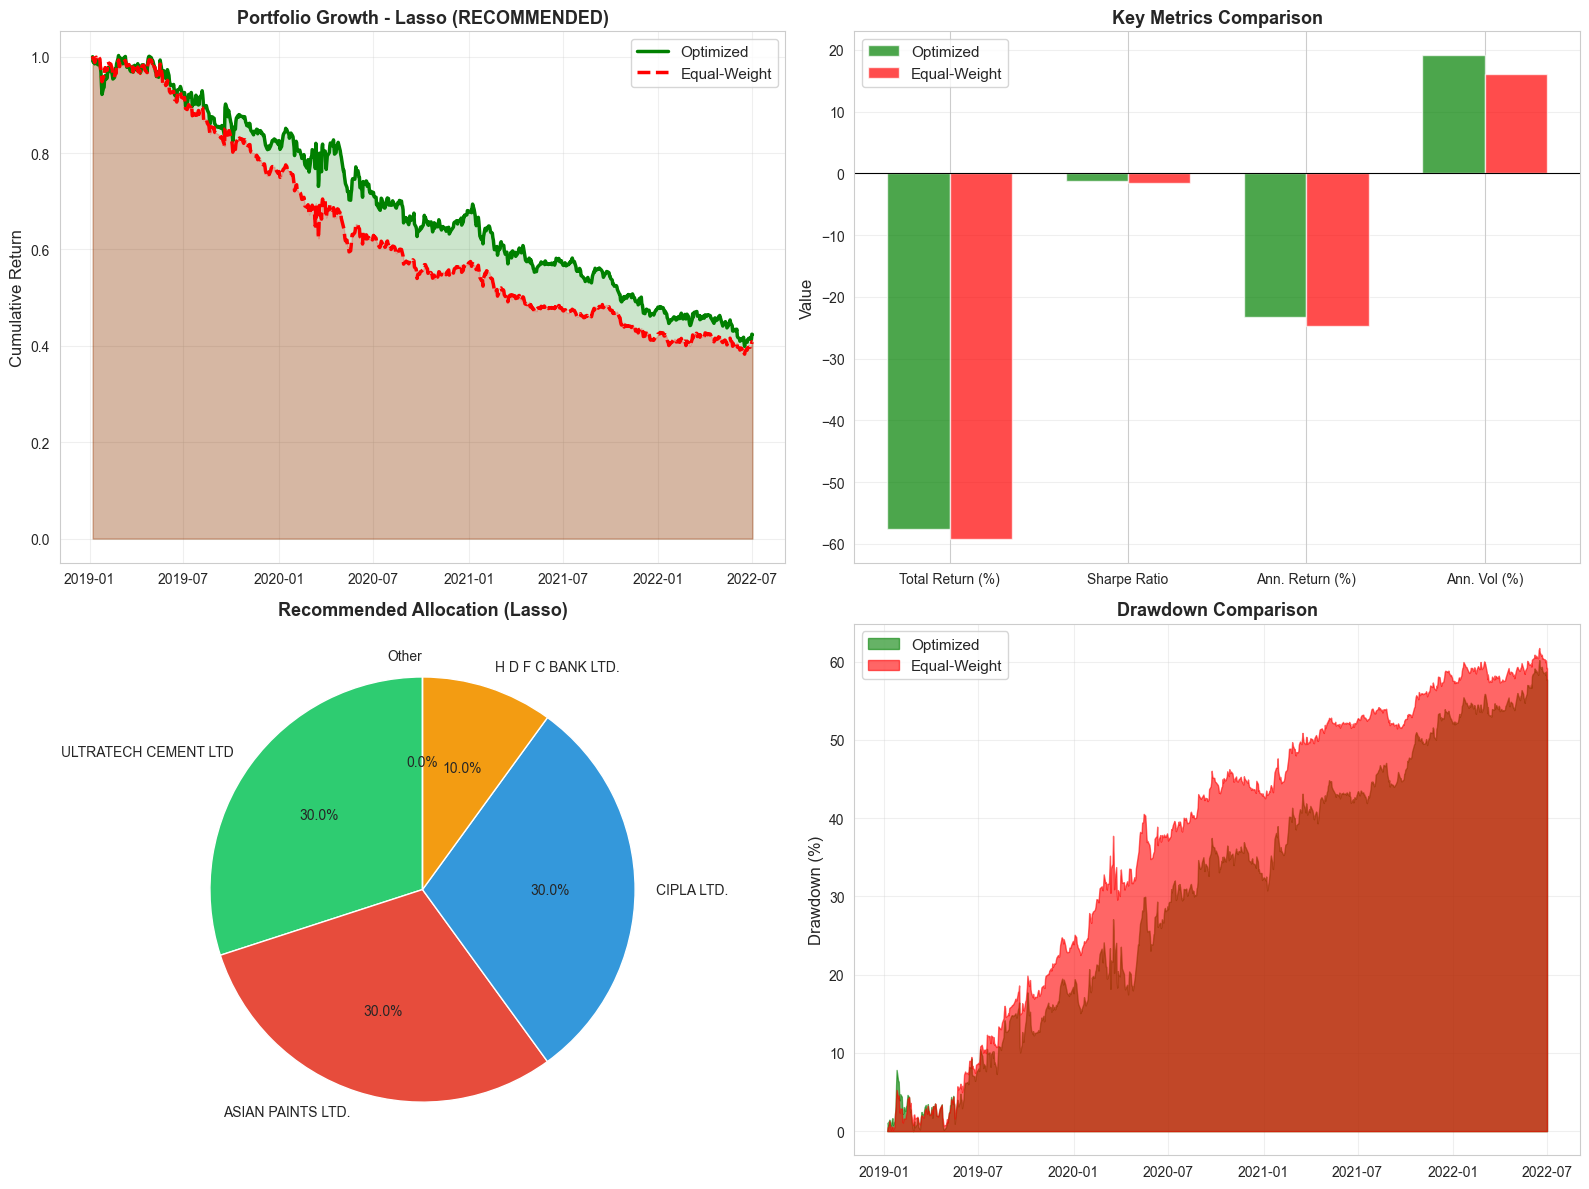


OPTIMIZED PORTFOLIO:
  Total Return:  -57.63%
  Annualized Return:  -23.19%
  Annualized Volatility:  19.09%
  Sharpe Ratio: -1.2145

EQUAL-WEIGHT PORTFOLIO:
  Total Return:  -59.17%
  Annualized Return:  -24.80%
  Annualized Volatility:  16.06%
  Sharpe Ratio: -1.5440


In [18]:
best_model_name = model_df.iloc[0]['Model']
worst_model_name = model_df.iloc[-1]['Model']

print(f"\n{'='*130}")
print(f"BEST MODEL & PORTFOLIO SELECTION")
print(f"{'='*130}\n")
print(f"Best Model (by R²): {best_model_name} (R² = {model_df.iloc[0]['R2']:.6f})")
print(f"Worst Model (by R²): {worst_model_name} (R² = {model_df.iloc[-1]['R2']:.6f})")

best_bt_data = backtest_comparison[best_model_name]
print(f"\n{best_model_name.upper()} PORTFOLIO vs EQUAL-WEIGHT:")
print(f"  Optimized - Total Return: {best_bt_data['total_opt']:7.2f}% | Sharpe: {best_bt_data['sharpe_opt']:7.4f}")
print(f"  Equal-Wgt - Total Return: {best_bt_data['total_eq']:7.2f}% | Sharpe: {best_bt_data['sharpe_eq']:7.4f}")
sharpe_diff = best_bt_data['sharpe_opt'] - best_bt_data['sharpe_eq']
print(f"  Difference: Sharpe {sharpe_diff:+.4f} (Optimized {'wins' if sharpe_diff > 0 else 'loses'})")

best_pf_data = portfolio_results[best_model_name]
best_tickers = best_pf_data['tickers']
best_weights = best_pf_data['opt_weights']

print(f"\nRECOMMENDED PORTFOLIO ({best_model_name}):")
pf_alloc = pd.DataFrame({
    'Ticker': best_tickers,
    'Weight_%': best_weights * 100,
    'Pred_Return_%': best_pf_data['rank']['Pred_Return'].values * 100,
    'Volatility_%': best_pf_data['rank']['Volatility'].values * 100
}).sort_values('Weight_%', ascending=False)
print(pf_alloc[pf_alloc['Weight_%'] > 0.5].to_string(index=False))

print(f"\n{'='*130}")
print(f"FINAL COMPARISON: {best_model_name} OPTIMIZED vs EQUAL-WEIGHT")
print(f"{'='*130}\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(best_bt_data['cum_opt'].index, best_bt_data['cum_opt'].values, label='Optimized', linewidth=2.5, color='green')
axes[0, 0].plot(best_bt_data['cum_eq'].index, best_bt_data['cum_eq'].values, label='Equal-Weight', linewidth=2.5, color='red', linestyle='--')
axes[0, 0].fill_between(best_bt_data['cum_opt'].index, best_bt_data['cum_opt'].values, alpha=0.2, color='green')
axes[0, 0].fill_between(best_bt_data['cum_eq'].index, best_bt_data['cum_eq'].values, alpha=0.2, color='red')
axes[0, 0].set_ylabel('Cumulative Return', fontsize=12)
axes[0, 0].set_title(f'Portfolio Growth - {best_model_name} (RECOMMENDED)', fontweight='bold', fontsize=13)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

metrics_names = ['Total Return (%)', 'Sharpe Ratio', 'Ann. Return (%)', 'Ann. Vol (%)']
opt_vals = [best_bt_data['total_opt'], best_bt_data['sharpe_opt'], 
            best_bt_data['daily_opt'].mean() * 252 * 100, 
            best_bt_data['daily_opt'].std() * np.sqrt(252) * 100]
eq_vals = [best_bt_data['total_eq'], best_bt_data['sharpe_eq'],
           best_bt_data['daily_eq'].mean() * 252 * 100,
           best_bt_data['daily_eq'].std() * np.sqrt(252) * 100]

x_pos = np.arange(len(metrics_names))
width = 0.35
axes[0, 1].bar(x_pos - width/2, opt_vals, width, label='Optimized', color='green', alpha=0.7)
axes[0, 1].bar(x_pos + width/2, eq_vals, width, label='Equal-Weight', color='red', alpha=0.7)
axes[0, 1].set_ylabel('Value', fontsize=12)
axes[0, 1].set_title('Key Metrics Comparison', fontweight='bold', fontsize=13)
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(metrics_names, fontsize=10)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].axhline(0, color='black', linestyle='-', linewidth=0.8)

pf_plot = pf_alloc[pf_alloc['Weight_%'] > 0.5].copy()
if len(pf_alloc) > len(pf_plot):
    other_w = pf_alloc[pf_alloc['Weight_%'] <= 0.5]['Weight_%'].sum()
    pf_plot = pd.concat([pf_plot, pd.DataFrame({'Ticker': ['Other'], 'Weight_%': [other_w], 'Pred_Return_%': [0], 'Volatility_%': [0]})], ignore_index=True)

colors_pie = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
axes[1, 0].pie(pf_plot['Weight_%'], labels=[t[:20] for t in pf_plot['Ticker']], autopct='%1.1f%%', colors=colors_pie[:len(pf_plot)], startangle=90)
axes[1, 0].set_title(f'Recommended Allocation ({best_model_name})', fontweight='bold', fontsize=13)

dd_opt = (best_bt_data['cum_opt'].cummax() - best_bt_data['cum_opt']) / best_bt_data['cum_opt'].cummax() * 100
dd_eq = (best_bt_data['cum_eq'].cummax() - best_bt_data['cum_eq']) / best_bt_data['cum_eq'].cummax() * 100
axes[1, 1].fill_between(dd_opt.index, dd_opt.values, alpha=0.6, color='green', label='Optimized')
axes[1, 1].fill_between(dd_eq.index, dd_eq.values, alpha=0.6, color='red', label='Equal-Weight')
axes[1, 1].set_ylabel('Drawdown (%)', fontsize=12)
axes[1, 1].set_title('Drawdown Comparison', fontweight='bold', fontsize=13)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOPTIMIZED PORTFOLIO:")
print(f"  Total Return: {best_bt_data['total_opt']:7.2f}%")
print(f"  Annualized Return: {best_bt_data['daily_opt'].mean() * 252 * 100:7.2f}%")
print(f"  Annualized Volatility: {best_bt_data['daily_opt'].std() * np.sqrt(252) * 100:6.2f}%")
print(f"  Sharpe Ratio: {best_bt_data['sharpe_opt']:7.4f}")

print(f"\nEQUAL-WEIGHT PORTFOLIO:")
print(f"  Total Return: {best_bt_data['total_eq']:7.2f}%")
print(f"  Annualized Return: {best_bt_data['daily_eq'].mean() * 252 * 100:7.2f}%")
print(f"  Annualized Volatility: {best_bt_data['daily_eq'].std() * np.sqrt(252) * 100:6.2f}%")
print(f"  Sharpe Ratio: {best_bt_data['sharpe_eq']:7.4f}")

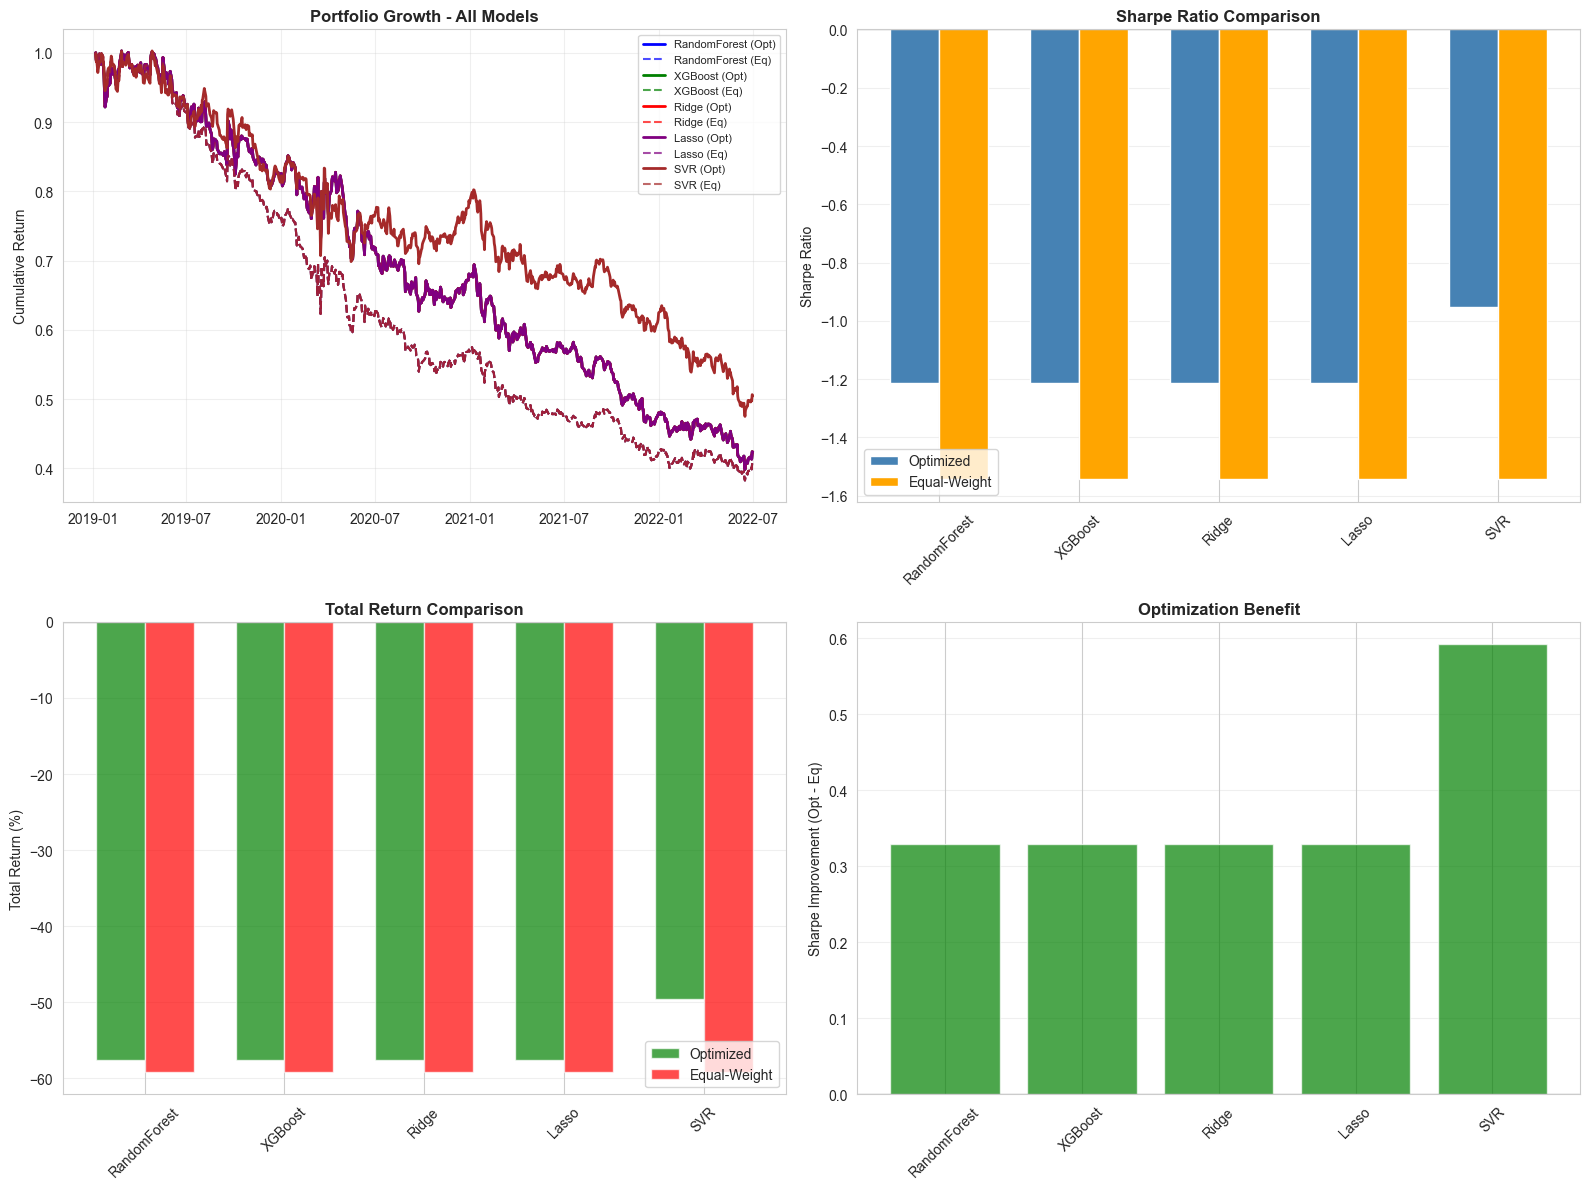

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors_map = {'RandomForest': 'blue', 'XGBoost': 'green', 'Ridge': 'red', 'Lasso': 'purple', 'SVR': 'brown'}

for model_name, bt_data in backtest_comparison.items():
    axes[0, 0].plot(bt_data['cum_opt'].index, bt_data['cum_opt'].values, label=f"{model_name} (Opt)", 
                    linewidth=2, color=colors_map[model_name], linestyle='-')
    axes[0, 0].plot(bt_data['cum_eq'].index, bt_data['cum_eq'].values, label=f"{model_name} (Eq)", 
                    linewidth=1.5, color=colors_map[model_name], linestyle='--', alpha=0.7)

axes[0, 0].set_ylabel('Cumulative Return')
axes[0, 0].set_title('Portfolio Growth - All Models', fontweight='bold')
axes[0, 0].legend(fontsize=8, loc='best')
axes[0, 0].grid(True, alpha=0.3)

sharpe_opt = [bt_data['sharpe_opt'] for bt_data in backtest_comparison.values()]
sharpe_eq = [bt_data['sharpe_eq'] for bt_data in backtest_comparison.values()]
model_names = list(backtest_comparison.keys())
x_pos = np.arange(len(model_names))
width = 0.35

axes[0, 1].bar(x_pos - width/2, sharpe_opt, width, label='Optimized', color='steelblue')
axes[0, 1].bar(x_pos + width/2, sharpe_eq, width, label='Equal-Weight', color='orange')
axes[0, 1].set_ylabel('Sharpe Ratio')
axes[0, 1].set_title('Sharpe Ratio Comparison', fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(model_names, rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].axhline(0, color='black', linestyle='-', linewidth=0.8)

total_opt = [bt_data['total_opt'] for bt_data in backtest_comparison.values()]
total_eq = [bt_data['total_eq'] for bt_data in backtest_comparison.values()]

axes[1, 0].bar(x_pos - width/2, total_opt, width, label='Optimized', color='green', alpha=0.7)
axes[1, 0].bar(x_pos + width/2, total_eq, width, label='Equal-Weight', color='red', alpha=0.7)
axes[1, 0].set_ylabel('Total Return (%)')
axes[1, 0].set_title('Total Return Comparison', fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(model_names, rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].axhline(0, color='black', linestyle='-', linewidth=0.8)

improvement = [(sharpe_opt[i] - sharpe_eq[i]) for i in range(len(model_names))]
colors_imp = ['green' if x > 0 else 'red' for x in improvement]
axes[1, 1].bar(x_pos, improvement, color=colors_imp, alpha=0.7)
axes[1, 1].set_ylabel('Sharpe Improvement (Opt - Eq)')
axes[1, 1].set_title('Optimization Benefit', fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(model_names, rotation=45)
axes[1, 1].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [20]:
best_pf_alloc = pd.DataFrame({
    'Ticker': best_tickers,
    'Weight_%': best_weights * 100,
    'Model': best_model_name,
    'Pred_Return_%': best_pf_data['rank']['Pred_Return'].values * 100,
    'Volatility_%': best_pf_data['rank']['Volatility'].values * 100
}).sort_values('Weight_%', ascending=False)

rank.to_csv('Part3_Stock_Rankings.csv', index=False)
best_pf_alloc.to_csv('Part3_RECOMMENDED_Portfolio_Allocation.csv', index=False)
pf.to_csv('Part3_Portfolio_Allocation_RandomForest.csv', index=False)

bt_export = pd.DataFrame({
    'Date': best_bt_data['cum_opt'].index,
    'Optimized': best_bt_data['cum_opt'].values,
    'Equal_Weight': best_bt_data['cum_eq'].values,
    'Daily_Opt': best_bt_data['daily_opt'].values,
    'Daily_Eq': best_bt_data['daily_eq'].values
})
bt_export.to_csv('Part3_RECOMMENDED_Backtest_Results.csv', index=False)

model_comparison_export = pd.DataFrame(model_results).T.reset_index()
model_comparison_export.columns = ['Model', 'R2', 'MAE', 'RMSE']
model_comparison_export.to_csv('Part3_Model_Comparison.csv', index=False)

portfolio_comparison_export = []
for model_name, pf_data in portfolio_results.items():
    for ticker, weight in zip(pf_data['tickers'], pf_data['opt_weights']):
        portfolio_comparison_export.append({
            'Model': model_name,
            'Ticker': ticker,
            'Weight': weight,
            'Opt_Return': pf_data['opt_ret'],
            'Opt_Risk': pf_data['opt_vol']
        })
portfolio_comp_df = pd.DataFrame(portfolio_comparison_export)
portfolio_comp_df.to_csv('Part3_Multi_Model_Portfolios.csv', index=False)

print("All exports complete!")
print(f"\n✓ RECOMMENDED FILES (use these):")
print(f"  - Part3_RECOMMENDED_Portfolio_Allocation.csv ({best_model_name} model)")
print(f"  - Part3_RECOMMENDED_Backtest_Results.csv ({best_model_name} backtest)")
print(f"\n✓ COMPARISON FILES (all models):")
print(f"  - Part3_Model_Comparison.csv ({len(model_comparison_export)} models)")
print(f"  - Part3_Multi_Model_Portfolios.csv (5 model allocations)")
print(f"  - Part3_Stock_Rankings.csv ({rank.shape[0]} companies)")
print(f"\nRaw outputs:")
print(f"  - Part3_Portfolio_Allocation_RandomForest.csv")
print(f"  - Part3_Backtest_Results.csv")

All exports complete!

✓ RECOMMENDED FILES (use these):
  - Part3_RECOMMENDED_Portfolio_Allocation.csv (Lasso model)
  - Part3_RECOMMENDED_Backtest_Results.csv (Lasso backtest)

✓ COMPARISON FILES (all models):
  - Part3_Model_Comparison.csv (5 models)
  - Part3_Multi_Model_Portfolios.csv (5 model allocations)
  - Part3_Stock_Rankings.csv (6 companies)

Raw outputs:
  - Part3_Portfolio_Allocation_RandomForest.csv
  - Part3_Backtest_Results.csv


NameError: name 'cum_opt' is not defined

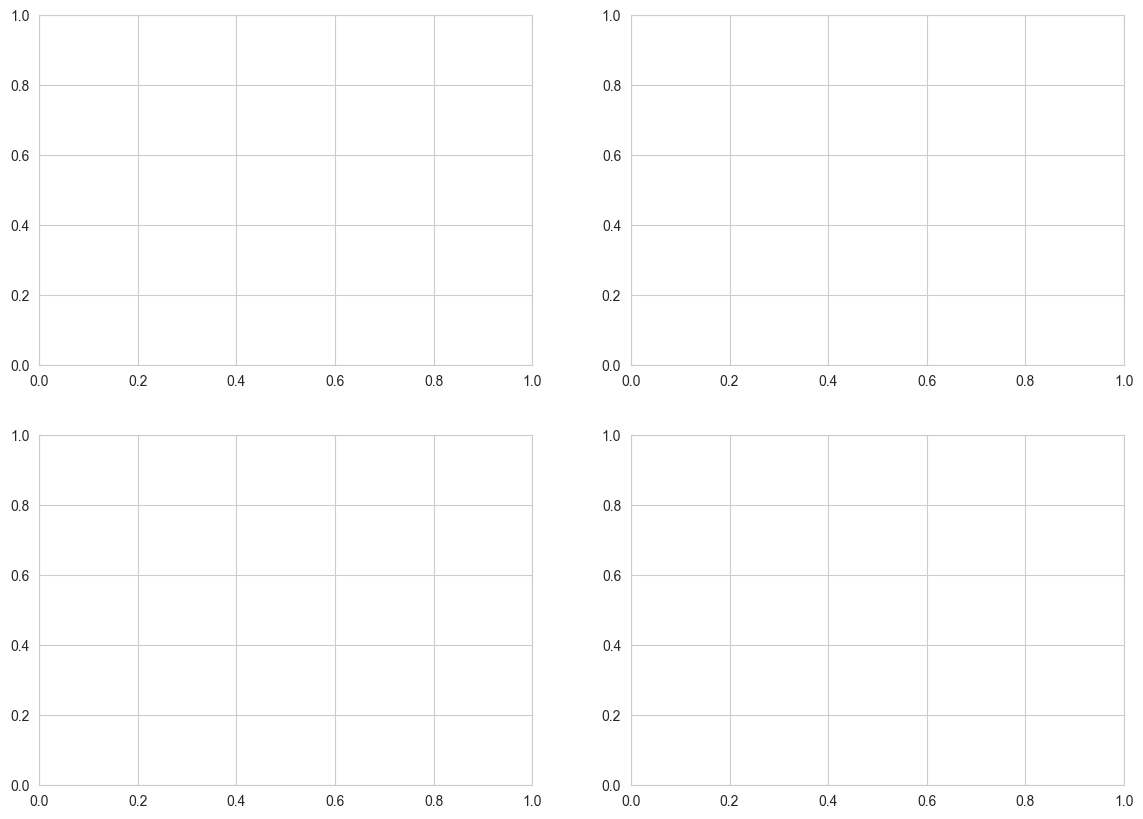

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(cum_opt.index, cum_opt.values, label='Optimized', linewidth=2, color='green')
axes[0, 0].plot(cum_eq.index, cum_eq.values, label='Equal-Weight', linewidth=2, color='orange')
axes[0, 0].set_ylabel('Cumulative Return')
axes[0, 0].set_title('Portfolio Growth', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

daily_opt_ret = daily_opt
daily_eq_ret = daily_eq
axes[0, 1].hist(daily_opt_ret*100, bins=50, alpha=0.6, label='Optimized', color='green')
axes[0, 1].hist(daily_eq_ret*100, bins=50, alpha=0.6, label='Equal-Weight', color='orange')
axes[0, 1].set_xlabel('Daily Return (%)')
axes[0, 1].set_title('Return Distribution', fontweight='bold')
axes[0, 1].legend()

dd_opt = (cum_opt.cummax() - cum_opt) / cum_opt.cummax() * 100
dd_eq = (cum_eq.cummax() - cum_eq) / cum_eq.cummax() * 100
axes[1, 0].fill_between(dd_opt.index, dd_opt.values, alpha=0.6, color='green', label='Optimized')
axes[1, 0].fill_between(dd_eq.index, dd_eq.values, alpha=0.6, color='orange', label='Equal-Weight')
axes[1, 0].set_ylabel('Drawdown (%)')
axes[1, 0].set_title('Drawdown', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

rolling_sharpe_opt = daily_opt_ret.rolling(30).mean() / daily_opt_ret.rolling(30).std() * np.sqrt(252)
rolling_sharpe_eq = daily_eq_ret.rolling(30).mean() / daily_eq_ret.rolling(30).std() * np.sqrt(252)
axes[1, 1].plot(rolling_sharpe_opt.index, rolling_sharpe_opt.values, label='Optimized', linewidth=2, color='green')
axes[1, 1].plot(rolling_sharpe_eq.index, rolling_sharpe_eq.values, label='Equal-Weight', linewidth=2, color='orange')
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_ylabel('Sharpe Ratio')
axes[1, 1].set_title('Rolling 30-Day Sharpe', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Export Results

In [ ]:
rank.to_csv('Part3_Stock_Rankings.csv', index=False)
pf.to_csv('Part3_Portfolio_Allocation.csv', index=False)

bt_export = pd.DataFrame({
    'Date': cum_opt.index,
    'Optimized': cum_opt.values,
    'Equal_Weight': cum_eq.values,
    'Daily_Opt': daily_opt.values,
    'Daily_Eq': daily_eq.values
})
bt_export.to_csv('Part3_Backtest_Results.csv', index=False)

model_comparison_export = pd.DataFrame(model_results).T.reset_index()
model_comparison_export.columns = ['Model', 'R2', 'MAE', 'RMSE']
model_comparison_export.to_csv('Part3_Model_Comparison.csv', index=False)

portfolio_comparison_export = []
for model_name, pf_data in portfolio_results.items():
    for ticker, weight in zip(pf_data['tickers'], pf_data['opt_weights']):
        portfolio_comparison_export.append({
            'Model': model_name,
            'Ticker': ticker,
            'Weight': weight,
            'Opt_Return': pf_data['opt_ret'],
            'Opt_Risk': pf_data['opt_vol']
        })
portfolio_comp_df = pd.DataFrame(portfolio_comparison_export)
portfolio_comp_df.to_csv('Part3_Multi_Model_Portfolios.csv', index=False)

print("All exports complete!")
print(f"- Part3_Stock_Rankings.csv ({rank.shape[0]} companies)")
print(f"- Part3_Portfolio_Allocation.csv")
print(f"- Part3_Backtest_Results.csv ({len(bt_export)} days)")
print(f"- Part3_Model_Comparison.csv ({len(model_comparison_export)} models)")
print(f"- Part3_Multi_Model_Portfolios.csv (allocations for all {len(portfolio_results)} models)")